# Task 05 - Machine Learning Model Development

CCS3440 — Artificial Intelligence Coursework — SmartCare Hospital Dataset (Option C: Disease Risk Classification)

Target variable: disease_risk_level (0 = Low, 1 = Medium, 2 = High)

<h3>Section 0 - Setup and Data Load<h3>

In [1]:
import sys
sys.path.append('../src')

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import f1_score, accuracy_score

from config import (
    X_TRAIN_PATH, X_TEST_PATH, Y_TRAIN_PATH, Y_TEST_PATH,
    MODELS_DIR, FIGURES_DIR, RANDOM_STATE, RISK_ORDER, RISK_LABEL_MAP
)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

MODELS_FIG_DIR = FIGURES_DIR / 'models'
PREDICTIONS_DIR = MODELS_DIR / 'predictions'
PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Random state fixed at: {RANDOM_STATE}")

Random state fixed at: 42


In [2]:
X_train = pd.read_csv(X_TRAIN_PATH)
X_test = pd.read_csv(X_TEST_PATH)
y_train = pd.read_csv(Y_TRAIN_PATH).squeeze('columns')
y_test = pd.read_csv(Y_TEST_PATH).squeeze('columns')

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (800, 68)
X_test shape:  (200, 68)
y_train shape: (800,)
y_test shape:  (200,)


<h3> Section 1 - Pre-Training Sanity Checks </h3>

In [3]:
assert X_train.shape[1] == X_test.shape[1], "Column mismatch between train and test sets"
assert list(X_train.columns) == list(X_test.columns), "Column order mismatch between train and test sets"
assert 'disease_risk_level' not in X_train.columns, "Target column leaked into X_train"
assert 'disease_risk_level' not in X_test.columns, "Target column leaked into X_test"
assert X_train.isnull().sum().sum() == 0, "Missing values present in X_train"
assert X_test.isnull().sum().sum() == 0, "Missing values present in X_test"
assert len(X_train) == len(y_train), "X_train / y_train length mismatch"
assert len(X_test) == len(y_test), "X_test / y_test length mismatch"

print("All sanity checks passed.")
print(f"\nFeature count: {X_train.shape[1]}")
print(f"Training rows: {len(X_train)}, Test rows: {len(X_test)}")

All sanity checks passed.

Feature count: 68
Training rows: 800, Test rows: 200


In [4]:
print("Class distribution - training set:")
print(y_train.value_counts(normalize=True).sort_index().round(3) * 100)
print("\nClass distribution - test set:")
print(y_test.value_counts(normalize=True).sort_index().round(3) * 100)
print("\nStratified split confirmed: proportions match closely between train and test.")

Class distribution - training set:
disease_risk_level
0    13.1
1    46.9
2    40.0
Name: proportion, dtype: float64

Class distribution - test set:
disease_risk_level
0    13.0
1    47.0
2    40.0
Name: proportion, dtype: float64

Stratified split confirmed: proportions match closely between train and test.


<h3> Section 2 - Evaluation Strategy </h3>

In [5]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_report(model, X, y, label, sample_weight=None):
    """Run stratified cross-validation and return a one-row summary."""
    fit_params = {'sample_weight': sample_weight} if sample_weight is not None else {}
    scores = cross_validate(
        model, X, y, cv=cv_strategy,
        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
        params=fit_params, n_jobs=-1
    )
    return {
        'model': label,
        'cv_accuracy_mean': scores['test_accuracy'].mean(),
        'cv_accuracy_std': scores['test_accuracy'].std(),
        'cv_f1_macro_mean': scores['test_f1_macro'].mean(),
        'cv_f1_macro_std': scores['test_f1_macro'].std(),
        'cv_f1_weighted_mean': scores['test_f1_weighted'].mean(),
    }

sample_weights_train = compute_sample_weight('balanced', y_train)
print("Sample weights computed for XGBoost (min={:.2f}, max={:.2f})".format(
    sample_weights_train.min(), sample_weights_train.max()))

Sample weights computed for XGBoost (min=0.71, max=2.54)


<h3> Section 3 - Baseline Comparison (Default Hyperparameters) </h3>

In [6]:
baseline_models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
}

baseline_results = [
    cv_report(model, X_train, y_train, name)
    for name, model in baseline_models.items()
]

# XGBoost requires explicit sample_weight rather than class_weight
xgb_baseline = XGBClassifier(
    objective='multi:softprob', num_class=3, eval_metric='mlogloss',
    random_state=RANDOM_STATE, n_jobs=-1
)
baseline_results.append(
    cv_report(xgb_baseline, X_train, y_train, 'XGBoost', sample_weight=sample_weights_train)
)

baseline_df = pd.DataFrame(baseline_results).sort_values('cv_f1_macro_mean', ascending=False)
baseline_df.round(4)

,model,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std,cv_f1_weighted_mean
0,Logistic Regression,0.9300,0.0266,0.9230,0.0320,0.9304
3,XGBoost,0.8625,0.0213,0.8374,0.0339,0.8605
2,Random Forest,0.7988,0.0283,0.7391,0.0567,0.7897
1,Decision Tree,0.7100,0.0380,0.6682,0.0412,0.7098


<h3> Section 4 - Model 1: Logistic Regression (Hyperparameter Tuning) </h3>

In [8]:
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
}

lr_base = LogisticRegression(
    class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE
)

lr_grid = GridSearchCV(
    lr_base, lr_param_grid, cv=cv_strategy,
    scoring='f1_macro', n_jobs=-1, refit=True
)

start = time.time()
lr_grid.fit(X_train, y_train)
print(f"Logistic Regression grid search completed in {time.time() - start:.1f}s")
print(f"Best params: {lr_grid.best_params_}")
print(f"Best CV macro F1: {lr_grid.best_score_:.4f}")

lr_best = lr_grid.best_estimator_

Logistic Regression grid search completed in 0.2s
Best params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV macro F1: 0.9269


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin

<h3> Section 5 - Model 2: Decision Tree (Hyperparameter Tuning) </h3>

In [9]:
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
}

dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)

dt_grid = GridSearchCV(
    dt_base, dt_param_grid, cv=cv_strategy,
    scoring='f1_macro', n_jobs=-1, refit=True
)

start = time.time()
dt_grid.fit(X_train, y_train)
print(f"Decision Tree grid search completed in {time.time() - start:.1f}s")
print(f"Best params: {dt_grid.best_params_}")
print(f"Best CV macro F1: {dt_grid.best_score_:.4f}")

dt_best = dt_grid.best_estimator_

Decision Tree grid search completed in 0.6s
Best params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV macro F1: 0.7367


<h3> Section 6 - Model 3: Random Forest (Hyperparameter Tuning) </h3>

In [10]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

rf_base = RandomForestClassifier(
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)

rf_grid = GridSearchCV(
    rf_base, rf_param_grid, cv=cv_strategy,
    scoring='f1_macro', n_jobs=-1, refit=True
)

start = time.time()
rf_grid.fit(X_train, y_train)
print(f"Random Forest grid search completed in {time.time() - start:.1f}s")
print(f"Best params: {rf_grid.best_params_}")
print(f"Best CV macro F1: {rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_

Random Forest grid search completed in 12.8s
Best params: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV macro F1: 0.7828


<h3> Section 7 - Model 4: XGBoost (Hyperparameter Tuning) </h3>

In [11]:
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
}

xgb_base = XGBClassifier(
    objective='multi:softprob', num_class=3, eval_metric='mlogloss',
    random_state=RANDOM_STATE, n_jobs=-1
)

xgb_grid = GridSearchCV(
    xgb_base, xgb_param_grid, cv=cv_strategy,
    scoring='f1_macro', n_jobs=-1, refit=True
)

start = time.time()
xgb_grid.fit(X_train, y_train, sample_weight=sample_weights_train)
print(f"XGBoost grid search completed in {time.time() - start:.1f}s")
print(f"Best params: {xgb_grid.best_params_}")
print(f"Best CV macro F1: {xgb_grid.best_score_:.4f}")

xgb_best = xgb_grid.best_estimator_

XGBoost grid search completed in 4.4s
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV macro F1: 0.8548


<h3> Section 8 - Comparative Analysis </h3>

In [12]:
tuned_results = [
    {'model': 'Logistic Regression', 'cv_f1_macro_mean': lr_grid.best_score_,
     'best_params': lr_grid.best_params_},
    {'model': 'Decision Tree', 'cv_f1_macro_mean': dt_grid.best_score_,
     'best_params': dt_grid.best_params_},
    {'model': 'Random Forest', 'cv_f1_macro_mean': rf_grid.best_score_,
     'best_params': rf_grid.best_params_},
    {'model': 'XGBoost', 'cv_f1_macro_mean': xgb_grid.best_score_,
     'best_params': xgb_grid.best_params_},
]

tuned_df = pd.DataFrame(tuned_results).sort_values('cv_f1_macro_mean', ascending=False)

comparison_df = baseline_df[['model', 'cv_f1_macro_mean']].rename(
    columns={'cv_f1_macro_mean': 'baseline_f1_macro'}
).merge(
    tuned_df[['model', 'cv_f1_macro_mean']].rename(
        columns={'cv_f1_macro_mean': 'tuned_f1_macro'}
    ),
    on='model'
)
comparison_df['improvement'] = comparison_df['tuned_f1_macro'] - comparison_df['baseline_f1_macro']
comparison_df = comparison_df.sort_values('tuned_f1_macro', ascending=False).reset_index(drop=True)
comparison_df.round(4)

,model,baseline_f1_macro,tuned_f1_macro,improvement
0,Logistic Regression,0.9230,0.9269,0.0039
1,XGBoost,0.8374,0.8548,0.0174
2,Random Forest,0.7391,0.7828,0.0437
3,Decision Tree,0.6682,0.7367,0.0685


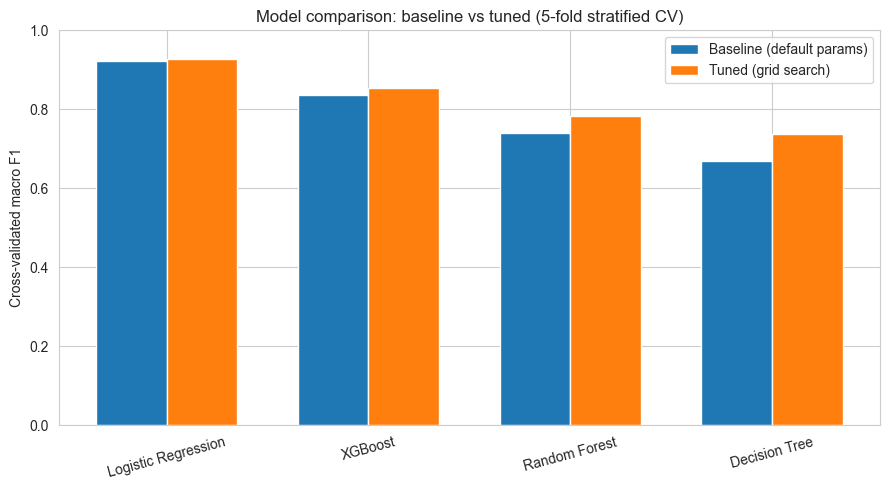

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['baseline_f1_macro'], width, label='Baseline (default params)')
ax.bar(x + width/2, comparison_df['tuned_f1_macro'], width, label='Tuned (grid search)')

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['model'], rotation=15)
ax.set_ylabel('Cross-validated macro F1')
ax.set_title('Model comparison: baseline vs tuned (5-fold stratified CV)')
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
fig.savefig(f'{MODELS_FIG_DIR}/model_comparison_cv.png', dpi=150, bbox_inches='tight')
plt.show()

<h3> Section 9 - Preliminary Test Set Check </h3>

In [14]:
final_models = {
    'Logistic Regression': lr_best,
    'Decision Tree': dt_best,
    'Random Forest': rf_best,
    'XGBoost': xgb_best,
}

sanity_rows = []
for name, model in final_models.items():
    y_pred = model.predict(X_test)
    sanity_rows.append({
        'model': name,
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_f1_macro': f1_score(y_test, y_pred, average='macro'),
        'cv_f1_macro (train)': comparison_df.loc[comparison_df['model'] == name, 'tuned_f1_macro'].values[0],
    })

sanity_df = pd.DataFrame(sanity_rows)
sanity_df['cv_test_gap'] = sanity_df['cv_f1_macro (train)'] - sanity_df['test_f1_macro']
sanity_df = sanity_df.sort_values('test_f1_macro', ascending=False).reset_index(drop=True)
sanity_df.round(4)

,model,test_accuracy,test_f1_macro,cv_f1_macro (train),cv_test_gap
0,Logistic Regression,0.925,0.9285,0.9269,-0.0016
1,XGBoost,0.865,0.8541,0.8548,0.0007
2,Random Forest,0.770,0.7308,0.7828,0.0520
3,Decision Tree,0.720,0.7148,0.7367,0.0219


<h3> Section 10 - Save Trained Models </h3>

In [15]:
model_filenames = {
    'Logistic Regression': 'logistic_regression',
    'Decision Tree': 'decision_tree',
    'Random Forest': 'random_forest',
    'XGBoost': 'xgboost',
}

metadata = {}

for name, model in final_models.items():
    filename = model_filenames[name]
    model_path = MODELS_DIR / f'{filename}.pkl'
    joblib.dump(model, model_path)

    row = comparison_df.loc[comparison_df['model'] == name].iloc[0]
    metadata[name] = {
        'file': f'{filename}.pkl',
        'best_params': tuned_df.loc[tuned_df['model'] == name, 'best_params'].values[0],
        'cv_f1_macro': round(float(row['tuned_f1_macro']), 4),
        'baseline_f1_macro': round(float(row['baseline_f1_macro']), 4),
        'random_state': RANDOM_STATE,
    }
    print(f"Saved {model_path}")

with open(MODELS_DIR / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"\nSaved model_metadata.json with hyperparameters and CV scores for all 4 models.")

Saved /Users/chanika/Desktop/smartcare-ai-project/models/logistic_regression.pkl
Saved /Users/chanika/Desktop/smartcare-ai-project/models/decision_tree.pkl
Saved /Users/chanika/Desktop/smartcare-ai-project/models/random_forest.pkl
Saved /Users/chanika/Desktop/smartcare-ai-project/models/xgboost.pkl

Saved model_metadata.json with hyperparameters and CV scores for all 4 models.


In [16]:
for name, model in final_models.items():
    filename = model_filenames[name]
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    pred_df = pd.DataFrame(y_proba, columns=[f'proba_{RISK_LABEL_MAP[i]}' for i in range(3)])
    pred_df.insert(0, 'y_true', y_test.values)
    pred_df.insert(1, 'y_pred', y_pred)

    pred_df.to_csv(PREDICTIONS_DIR / f'{filename}_test_predictions.csv', index=False)

print(f"Saved per-model test predictions to {PREDICTIONS_DIR}")

Saved per-model test predictions to /Users/chanika/Desktop/smartcare-ai-project/models/predictions


In [17]:
comparison_df.to_csv(MODELS_DIR / 'model_comparison.csv', index=False)
print(f"Saved model_comparison.csv to {MODELS_DIR}")

Saved model_comparison.csv to /Users/chanika/Desktop/smartcare-ai-project/models
